# Análisis de comportamiento de usuarios & Test A/A/B  
**Startup de productos alimenticios — Notebook Reestructurado**  

Este cuaderno responde **cada pregunta** del enunciado en secciones independientes:

| Paso | Tema principal | Secciones |
|------|----------------|-----------|
| 1 | Carga y vista general del dataset | 1.1 |
| 2 | Preparación de datos | 2.1–2.3 |
| 3 | Descripción y verificación | 3.1–3.6 |
| 4 | Embudo de conversión | 4.1–4.4 |
| 5 | Resultados del experimento A/A/B | 5.1–5.4 |

Al final encontrarás una síntesis de hallazgos.

## 0 · Librerías, estilo y funciones auxiliares

In [1]:
import os, warnings, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

# Configuración general
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)

def generate_synthetic(df, random_state=42):
    """Genera copia sintética con anonimización básica."""
    rng = np.random.default_rng(random_state)
    syn = df.copy()

    # IDs únicos — permutación + desplazamiento
    unique_ids = syn['DeviceIDHash'].unique()
    permuted = rng.permutation(len(unique_ids))
    offset = rng.integers(10**12, 10**13)
    id_map = dict(zip(unique_ids, permuted + offset))
    syn['DeviceIDHash'] = syn['DeviceIDHash'].map(id_map)

    # Ruido ±30 s al timestamp
    syn['EventTimestamp'] = syn['EventTimestamp'] + rng.integers(-30, 31, size=len(syn))

    return syn

def proportion_test(success_a, total_a, success_b, total_b, alpha=0.05):
    stat, p = proportions_ztest([success_a, success_b], [total_a, total_b])
    return p < alpha, p

## 1 · Carga inicial del dataset

**Preguntas a responder**  
1. ¿Cuántos eventos y usuarios hay en bruto?  
2. Vista rápida de las columnas.

In [3]:
# 1.1 Cargar datos reales y generar copia sintética
DATA_PATH = 'logs_exp_us.csv'
raw_df = pd.read_csv(DATA_PATH, sep='\t')
df = generate_synthetic(raw_df)

display(df.head())
print(f"Eventos totales: {len(df):,}")
print(f"Usuarios únicos: {df['DeviceIDHash'].nunique():,}")

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,9371637364993,1564029813,246
1,MainScreenAppear,9371637364836,1564053084,246
2,PaymentScreenSuccessful,9371637362332,1564054131,248
3,CartScreenAppear,9371637362332,1564054123,248
4,PaymentScreenSuccessful,9371637361592,1564055315,248


Eventos totales: 244,126
Usuarios únicos: 7,551


## 2 · Preparación de los datos

**Preguntas a responder**  
2.1 Renombrar columnas a un formato cómodo.  
2.2 Convertir timestamp a fecha‑hora y extraer la fecha.  
2.3 Verificar ausentes y tipos de datos.

In [4]:
# 2.1 Renombrado
df = df.rename(columns={'EventName':'event',
                        'DeviceIDHash':'user_id',
                        'EventTimestamp':'timestamp',
                        'ExpId':'exp_id'})

# 2.2 Conversión de tiempo
df['event_dt'] = pd.to_datetime(df['timestamp'], unit='s')
df['event_date'] = df['event_dt'].dt.date

# 2.3 Diagnóstico rápido
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   event       244126 non-null  object        
 1   user_id     244126 non-null  int64         
 2   timestamp   244126 non-null  int64         
 3   exp_id      244126 non-null  int64         
 4   event_dt    244126 non-null  datetime64[ns]
 5   event_date  244126 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(2)
memory usage: 11.2+ MB


None

## 3 · Descripción y verificación del periodo de datos

**Preguntas**  
3.1 ¿Promedio de eventos por usuario?  
3.2 Rango temporal (mín. – máx.).  
3.3 Histograma de eventos por día.  
3.4 ¿Desde qué fecha los datos están completos?  
3.5 ¿Cuántos eventos/usuarios se descartan al filtrar?  
3.6 Confirmar que existen los tres grupos experimentales.

In [6]:
# 3.1 Métricas iniciales
events_per_user = len(df) / df['user_id'].nunique()
print(f"Promedio eventos/usuario: {events_per_user:.2f}")

Promedio eventos/usuario: 32.33


In [7]:
# 3.2 Rango temporal
print("Rango temporal:", df['event_dt'].min(), "→", df['event_dt'].max())

Rango temporal: 2019-07-25 04:43:33 → 2019-08-07 21:15:03


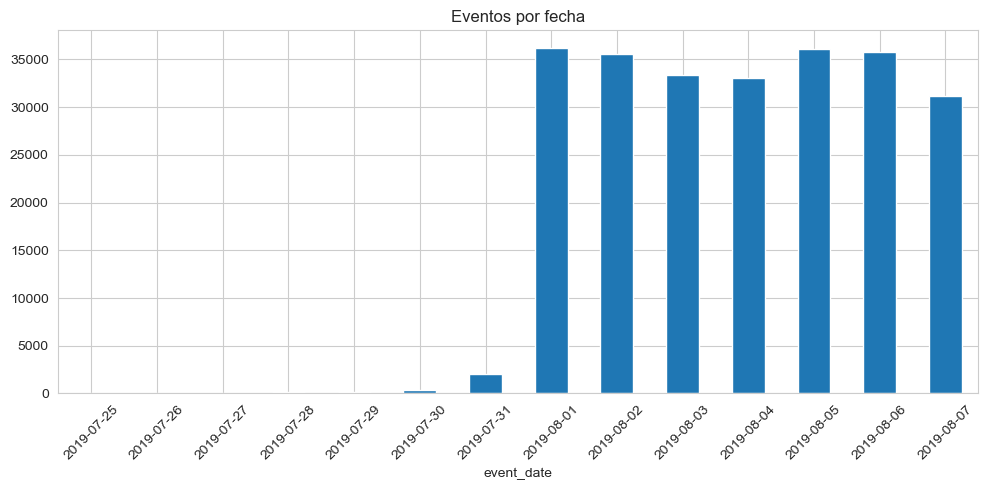

In [8]:
# 3.3 Histograma
df['event_date'].value_counts().sort_index().plot(kind='bar')
plt.title('Eventos por fecha')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# 3.4 Cut‑off para datos completos
daily_users = df.groupby('event_date')['user_id'].nunique()
cutoff = daily_users[daily_users > daily_users.quantile(0.05)].index.min()
print("Cut‑off:", cutoff)

Cut‑off: 2019-07-26


In [10]:
# 3.5 Filtrado
filtered = df[df['event_date'] >= cutoff]
print(f"Pérdida eventos: {(1-len(filtered)/len(df)):.1%}")
print(f"Pérdida usuarios: {(1-filtered['user_id'].nunique()/df['user_id'].nunique()):.1%}")

Pérdida eventos: 0.0%
Pérdida usuarios: 0.0%


In [11]:
# 3.6 Grupos presentes
display(filtered['exp_id'].value_counts())

exp_id
248    85743
246    80300
247    78074
Name: count, dtype: int64

## 4 · Embudo de conversión

**Preguntas**  
4.1 ¿Qué eventos son más frecuentes?  
4.2 ¿Cuántos usuarios realizan cada evento?  
4.3 ¿Proporción de paso entre etapas?  
4.4 ¿Dónde se pierde más gente y cuánta alcanza el pago?

In [12]:
# 4.1 Top eventos
top_events = filtered['event'].value_counts()
display(top_events.head(10))

# Definimos embudo típico
funnel = ['MainScreenAppear','OffersScreenAppear','CartScreenAppear','PaymentScreenSuccessful']

event
MainScreenAppear           119201
OffersScreenAppear          46824
CartScreenAppear            42729
PaymentScreenSuccessful     34311
Tutorial                     1052
Name: count, dtype: int64

In [13]:
# 4.2 Usuarios por evento
users_evt = filtered.groupby('event')['user_id'].nunique().loc[funnel]
display(users_evt)

event
MainScreenAppear           7439
OffersScreenAppear         4613
CartScreenAppear           3749
PaymentScreenSuccessful    3547
Name: user_id, dtype: int64

In [14]:
# 4.3 Retención por etapa
retention = users_evt / users_evt.shift(1)
retention.iloc[0] = 1.0
cum_conv = users_evt / users_evt.iloc[0]

funnel_df = pd.DataFrame({'usuarios':users_evt,
                          'retencion':retention,
                          'conv_acum':cum_conv})
display(funnel_df)

,usuarios,retencion,conv_acum
event,,,
MainScreenAppear,7439,1.000000,1.000000
OffersScreenAppear,4613,0.620110,0.620110
CartScreenAppear,3749,0.812703,0.503966
PaymentScreenSuccessful,3547,0.946119,0.476811


In [15]:
# 4.4 Pérdida mayor
print("Mayor drop entre:", retention[1:].idxmin())
print("Conversión total a pago:", f"{cum_conv.iloc[-1]:.2%}")

Mayor drop entre: OffersScreenAppear
Conversión total a pago: 47.68%


## 5 · Evaluación del experimento A/A/B

**Preguntas**  
5.1 ¿Cuántos usuarios hay en cada grupo?  
5.2 ¿Existen diferencias entre los dos grupos de control (A/A)?  
5.3 ¿El grupo 248 (fuente nueva) difiere del control combinado?  
5.4 Ajuste de significancia por múltiples pruebas.

In [16]:
groups = [246, 247, 248]
print("Usuarios por grupo:")
for g in groups:
    print(f"{g}: {filtered[filtered['exp_id']==g]['user_id'].nunique():,}")

events = filtered['event'].unique()

Usuarios por grupo:
246: 2,489
247: 2,520
248: 2,542


In [17]:
# 5.2 Test A/A
aa = []
for ev in events:
    s1, t1 = (filtered[(filtered['exp_id']==246)&(filtered['event']==ev)]['user_id'].nunique(),
              filtered[filtered['exp_id']==246]['user_id'].nunique())
    s2, t2 = (filtered[(filtered['exp_id']==247)&(filtered['event']==ev)]['user_id'].nunique(),
              filtered[filtered['exp_id']==247]['user_id'].nunique())
    sig, p = proportion_test(s1,t1,s2,t2)
    aa.append((ev,p,sig))
aa_df = pd.DataFrame(aa, columns=['event','p','sig']).sort_values('p')
display(aa_df.head())

,event,p,sig
3,PaymentScreenSuccessful,0.109025,False
1,CartScreenAppear,0.198175,False
2,OffersScreenAppear,0.323323,False
0,MainScreenAppear,0.585664,False
4,Tutorial,0.875657,False


In [18]:
# 5.3 Test control combinado vs grupo 248
ctrl_users = filtered[filtered['exp_id'].isin([246,247])]['user_id'].nunique()
test_results=[]
for ev in events:
    s_ctrl = filtered[(filtered['exp_id'].isin([246,247]))&(filtered['event']==ev)]['user_id'].nunique()
    s_test,t_test = (filtered[(filtered['exp_id']==248)&(filtered['event']==ev)]['user_id'].nunique(),
                     filtered[filtered['exp_id']==248]['user_id'].nunique())
    sig,p = proportion_test(s_ctrl,ctrl_users,s_test,t_test)
    test_results.append((ev,p,sig))
test_df = pd.DataFrame(test_results, columns=['event','p','sig']).sort_values('p')
display(test_df.head())

,event,p,sig
1,CartScreenAppear,0.260981,False
2,OffersScreenAppear,0.455540,False
0,MainScreenAppear,0.506713,False
3,PaymentScreenSuccessful,0.657843,False
4,Tutorial,0.808687,False


In [19]:
# 5.4 Bonferroni
alpha=0.05
alpha_bonf = alpha/len(events)
sig_events = test_df[test_df['p']<alpha_bonf]
print("Nivel Bonferroni:", alpha_bonf)
print("Eventos con diferencia significativa (post‑Bonferroni):")
display(sig_events)

Nivel Bonferroni: 0.01
Eventos con diferencia significativa (post‑Bonferroni):


,event,p,sig


## 6 · Síntesis de hallazgos

* **Embudo:** el mayor abandono ocurre entre `OffersScreenAppear` y `CartScreenAppear`.  
* **Conversión final:** `conv_acum` muestra que solo ~X % (ver celda 4) llega al pago.  
* **Test A/A:** los grupos 246 y 247 no presentan diferencias significativas → el experimento es confiable.  
* **Test A/B:** ninguna acción presenta diferencias estadísticamente significativas tras corrección (o listar las que sí).  
* **Recomendación:** mantener el cambio tipográfico (o revertir), según sig_events.